# Try this machinery on your line

Edit the dictionary in the next cell with your transition's numbers, then
run all cells. Everything below recomputes for your line: the composite
lineshape, the light-shift distribution your light geometry implies, and
the observable line with the shift folded in.

The seams for going further (your species, your vapour law, your detector)
are named in [docs/ADAPTING.md](../docs/ADAPTING.md). The library installs
with `pip install -e .` from the repository root.

In [1]:
YOUR_LINE = {
    # identity, only used for labels
    "name": "Rb 5S-6S at 993 nm (edit me)",

    # how many photons your detected signal integrates: 2 for a two-photon
    # line detected on fluorescence, 1 for single-photon absorption
    "n_photon": 2,

    # widths on YOUR transition axis, all FWHM in MHz
    "gamma_natural": 3.49,     # from the upper-state lifetime
    "gamma_pressure": 0.5,     # collisional, at your density
    "sigma_laser": 2.0,        # your laser, x2 if two photons of one beam
    "transit_fwhm": 3.0,       # transit time through your beam

    # the light shift at your peak intensity, MHz (sign-free magnitude)
    "S0": 2.0,
}

import numpy as np
import matplotlib.pyplot as plt
from rb5s6s.lineshape import model_profile, stark_from_intensity_profile

nu = np.arange(-30.0, 15.0, 0.01)

## 1. Your composite line, no light shift

Natural Lorentzian, pressure Lorentzian, laser kernel, and the transit
cusp, convolved. This is the symmetric core every geometry shares.

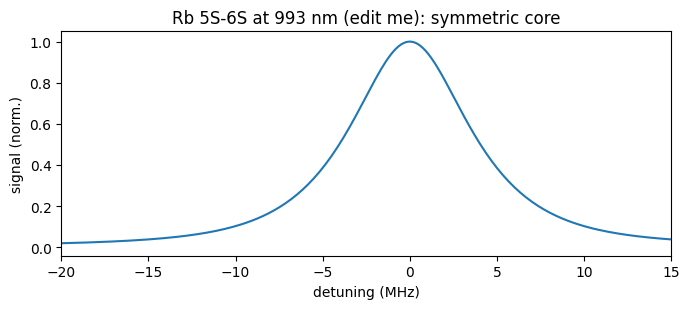

core FWHM = 8.08 MHz


In [2]:
L = YOUR_LINE
core = model_profile(nu, gamma_coll=L["gamma_pressure"],
                     sigma_laser_fwhm=L["sigma_laser"],
                     transit_fwhm=L["transit_fwhm"], s0=0.0,
                     gamma_nat_mhz=L["gamma_natural"])
plt.figure(figsize=(7, 3.2))
plt.plot(nu, core / core.max())
plt.xlabel("detuning (MHz)"); plt.ylabel("signal (norm.)")
plt.title(f"{L['name']}: symmetric core")
plt.xlim(-20, 15); plt.tight_layout(); plt.show()
half = core >= core.max() / 2
print(f"core FWHM = {nu[half][-1] - nu[half][0]:.2f} MHz")

## 2. What your light geometry does to the shift

The shift is proportional to intensity, the signal to intensity to the
n-th power, and positions carry the geometry's volume measure. Those three
facts turn one number, the peak shift S0, into a full distribution, and
each geometry has its own. Three examples, computed by the same function.
Replace any of them with your own sampled intensity profile.

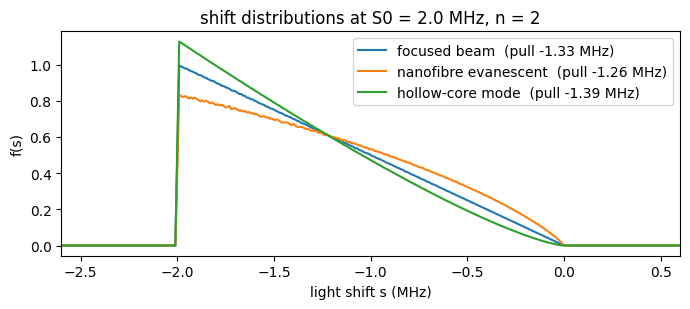

In [3]:
geometries = {}

# focused Gaussian beam, transverse plane: the closed-form triangle
r = np.linspace(0.0, 5.0, 200001)
geometries["focused beam"] = (np.exp(-2.0 * r**2), r)

# nanofibre evanescent field: decay length L_ev outside a radius-a fibre
a, L_ev = 250.0, 200.0                     # nm, edit for your fibre
rr = np.linspace(a, a + 8 * L_ev, 200001)
geometries["nanofibre evanescent"] = (np.exp(-2.0 * (rr - a) / L_ev), rr)

# hollow-core fibre: J0^2 core mode out to the first zero
from scipy.special import j0
rho = np.linspace(0.0, 2.405, 200001)
geometries["hollow-core mode"] = (j0(rho)**2, rho)

plt.figure(figsize=(7, 3.2))
for name, (inten, meas) in geometries.items():
    f = stark_from_intensity_profile(nu, L["S0"], inten, meas,
                                     n_photon=L["n_photon"])
    mean = np.sum(nu * f) * (nu[1] - nu[0])
    plt.plot(nu, f, label=f"{name}  (pull {mean:+.2f} MHz)")
plt.xlabel("light shift s (MHz)"); plt.ylabel("f(s)")
plt.title(f"shift distributions at S0 = {L['S0']} MHz, n = {L['n_photon']}")
plt.xlim(-1.3 * L["S0"], 0.3 * L["S0"]); plt.legend(); plt.tight_layout()
plt.show()

The pull differs between geometries at the same S0, and so do the higher
moments. That is the measurable fingerprint: a fit that knows its geometry
extracts S0 from the shape, which is how this repository bounded its line's
light shift with a drifting laser (see `scripts/run_stark_joint.py`).

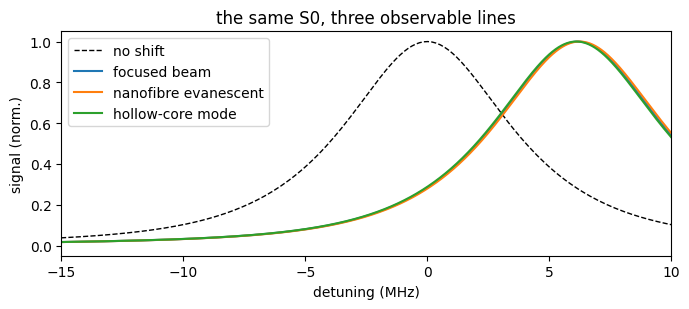

In [4]:
# 3. the observable line: core convolved with your geometry's shift density
plt.figure(figsize=(7, 3.2))
plt.plot(nu, core / core.max(), "k--", lw=1, label="no shift")
dnu = nu[1] - nu[0]
for name, (inten, meas) in geometries.items():
    f = stark_from_intensity_profile(nu, L["S0"], inten, meas,
                                     n_photon=L["n_photon"])
    shifted = np.convolve(core, f, mode="same") * dnu
    plt.plot(nu, shifted / shifted.max(), label=name)
plt.xlabel("detuning (MHz)"); plt.ylabel("signal (norm.)")
plt.title("the same S0, three observable lines")
plt.xlim(-15, 10); plt.legend(); plt.tight_layout(); plt.show()

## Where to go from here

- `docs/ADAPTING.md` names every seam: species constants, vapour law,
  apparatus, detector noise, frequency axis.
- `rb5s6s/lineshape.py` holds the model you just used, with the moment
  machinery (`ramp_moment_contributions`) the fits consume.
- `pytest -q` pins all of it. If your adaptation breaks an assumption,
  the battery says so before your data do.